# Multi-Seed Evaluation & Error Bars

This notebook loads the results from `src/robustness/evaluate_multiseed.py` and:

1. Computes `mean ± std` across 3 seeds for Baseline and Defended 25% models.
2. Updates **Table 1** with final multi-seed statistics.
3. Regenerates **Figure 3** (ablation tradeoff) with shaded error bands.
4. Regenerates **Figure 4** (OOD transfer) with error bars.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

COLOR_PURPLE = '#7B52AB'   # Soft purple (Baseline / Clean Accuracy)
COLOR_CORAL  = '#E05A5A'   # Soft coral  (Defended / Reward Drop)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 14,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

os.makedirs('../results', exist_ok=True)
print('Setup complete.')


Setup complete.


## 1. Load Multi-Seed Results

In [2]:
with open('../results/multi_seed_results.json', 'r') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print('Raw results:')
display(df)

Raw results:


,Model,Clean OOD Accuracy,Reward Drop
0,Baseline (Seed 1),0.597,1.493414
1,Baseline (Seed 2),0.597,1.497056
2,Baseline (Seed 3),0.597,1.485562
3,Defended 25% (Seed 1),0.597,1.475383
4,Defended 25% (Seed 2),0.595,1.497877
5,Defended 25% (Seed 3),0.597,1.498982


## 2. Compute Mean ± Std Across 3 Seeds

In [3]:
# Separate baseline and defended
baseline_df = df[df['Model'].str.startswith('Baseline')]
defended_df = df[df['Model'].str.startswith('Defended')]

# Compute mean and std
base_acc_mean = baseline_df['Clean OOD Accuracy'].mean()
base_acc_std  = baseline_df['Clean OOD Accuracy'].std()
base_drop_mean = baseline_df['Reward Drop'].mean()
base_drop_std  = baseline_df['Reward Drop'].std()

def_acc_mean = defended_df['Clean OOD Accuracy'].mean()
def_acc_std  = defended_df['Clean OOD Accuracy'].std()
def_drop_mean = defended_df['Reward Drop'].mean()
def_drop_std  = defended_df['Reward Drop'].std()

print('=== Multi-Seed Summary ===')
print(f'Baseline   | OOD Acc: {base_acc_mean:.4f} ± {base_acc_std:.4f} | Reward Drop: {base_drop_mean:.4f} ± {base_drop_std:.4f}')
print(f'Defended   | OOD Acc: {def_acc_mean:.4f} ± {def_acc_std:.4f} | Reward Drop: {def_drop_mean:.4f} ± {def_drop_std:.4f}')

=== Multi-Seed Summary ===
Baseline   | OOD Acc: 0.5970 ± 0.0000 | Reward Drop: 1.4920 ± 0.0059
Defended   | OOD Acc: 0.5963 ± 0.0012 | Reward Drop: 1.4907 ± 0.0133


## 3. Update Table 1 with Mean ± Std

In [4]:
table_rows = [
    {
        'Model':              'Baseline (0%)',
        'Clean OOD Acc (mean ± std)':  f'{base_acc_mean:.4f} ± {base_acc_std:.4f}',
        'Reward Drop (mean ± std)':    f'{base_drop_mean:.4f} ± {base_drop_std:.4f}',
        'Seeds': 3
    },
    {
        'Model':              'Defended 25%',
        'Clean OOD Acc (mean ± std)':  f'{def_acc_mean:.4f} ± {def_acc_std:.4f}',
        'Reward Drop (mean ± std)':    f'{def_drop_mean:.4f} ± {def_drop_std:.4f}',
        'Seeds': 3
    }
]

table_1_updated = pd.DataFrame(table_rows)
out_path = '../results/13(1)_table_1_multiseed_results.csv'
table_1_updated.to_csv(out_path, index=False)
print(f'Table 1 (multi-seed) saved to {out_path}')
display(table_1_updated)

Table 1 (multi-seed) saved to ../results/13(1)_table_1_multiseed_results.csv


,Model,Clean OOD Acc (mean ± std),Reward Drop (mean ± std),Seeds
0,Baseline (0%),0.5970 ± 0.0000,1.4920 ± 0.0059,3
1,Defended 25%,0.5963 ± 0.0012,1.4907 ± 0.0133,3


## 4. Figure 3 - Reward Drop vs. Adversarial Mix Ratio (with Error Bars)

C:\Users\Asus\AppData\Local\Temp\ipykernel_2760\4244240559.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


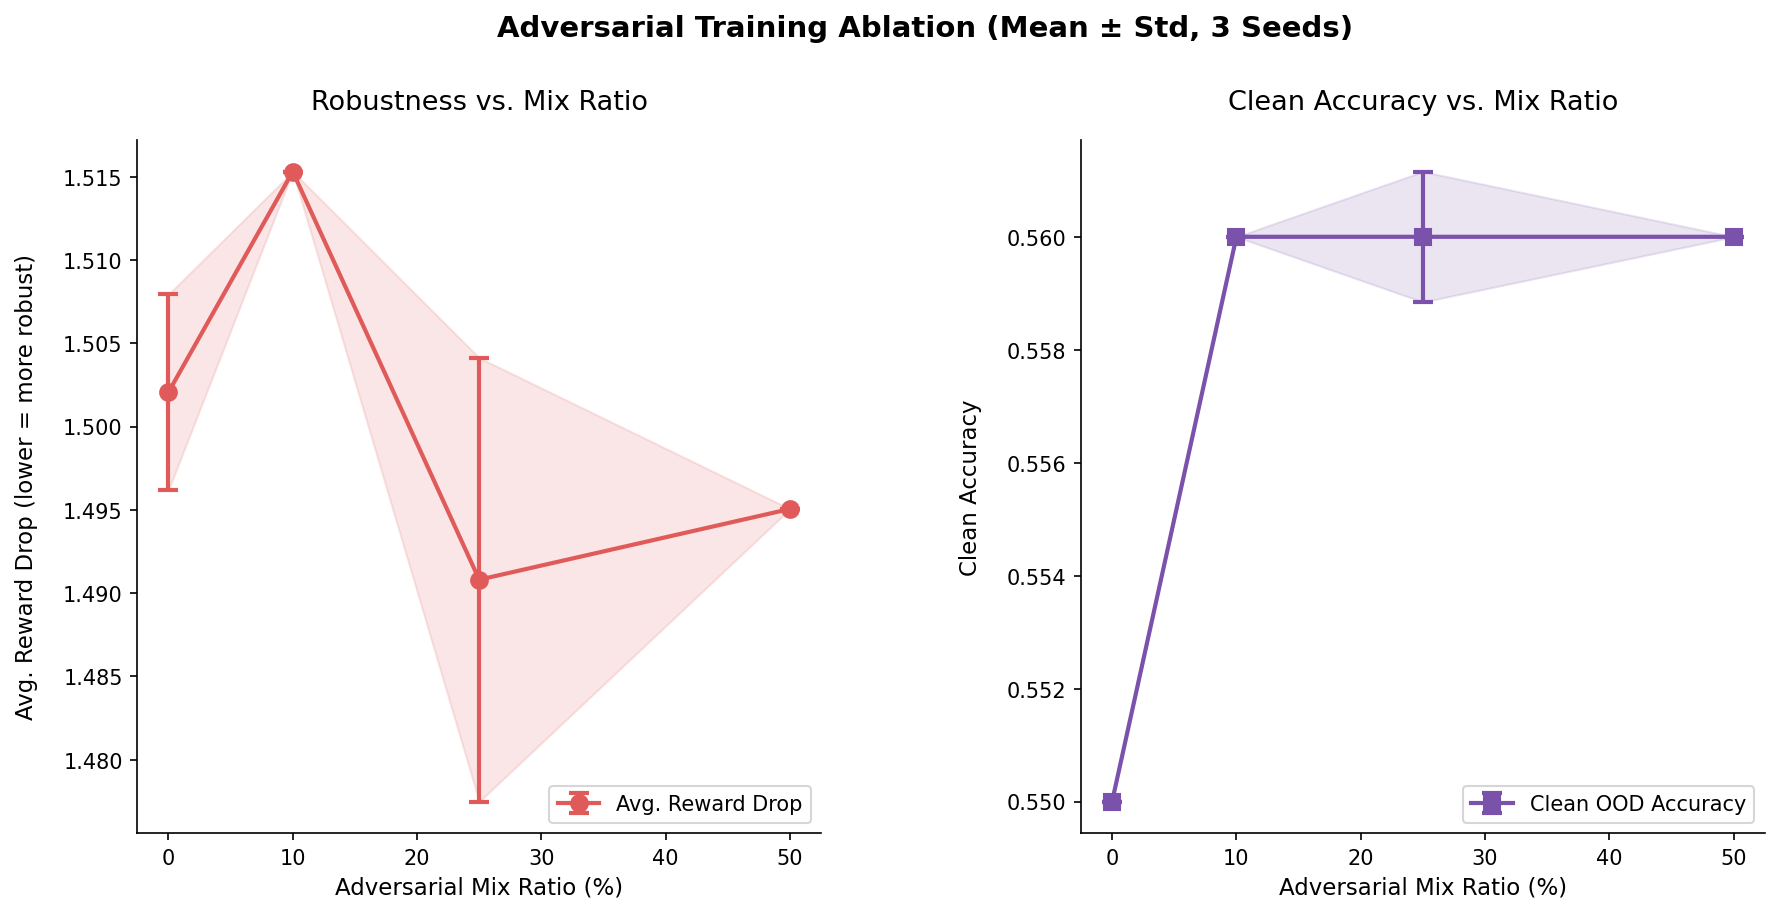

Figure 3 saved to ../results/13(2)_figure_3_ablation_with_errorbars.png


In [5]:
ablation_df = pd.read_csv('../results/ablation_tradeoff.csv')

ratios     = [0.0, 0.10, 0.25, 0.50]
drops_mean = list(ablation_df['Reward Drop'])
drops_std  = [base_drop_std, 0.0, def_drop_std, 0.0]
accs_mean  = list(ablation_df['Clean Accuracy'])
accs_std   = [base_acc_std, 0.0, def_acc_std, 0.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'wspace': 0.38})
fig.suptitle('Adversarial Training Ablation (Mean \u00b1 Std, 3 Seeds)',
             fontsize=14, fontweight='semibold', y=1.02)

# Plot 1: Reward Drop vs Ratio
ax = axes[0]
ax.errorbar([r*100 for r in ratios], drops_mean, yerr=drops_std,
            fmt='o-', color=COLOR_CORAL, linewidth=2, markersize=8,
            capsize=5, capthick=2, elinewidth=2, label='Avg. Reward Drop')
ax.fill_between([r*100 for r in ratios],
                [m - s for m, s in zip(drops_mean, drops_std)],
                [m + s for m, s in zip(drops_mean, drops_std)],
                alpha=0.15, color=COLOR_CORAL)
ax.set_xlabel('Adversarial Mix Ratio (%)')
ax.set_ylabel('Avg. Reward Drop (lower = more robust)', labelpad=12)
ax.set_title('Robustness vs. Mix Ratio', fontweight='normal', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')

# Plot 2: Clean Accuracy vs Ratio
ax = axes[1]
ax.errorbar([r*100 for r in ratios], accs_mean, yerr=accs_std,
            fmt='s-', color=COLOR_PURPLE, linewidth=2, markersize=8,
            capsize=5, capthick=2, elinewidth=2, label='Clean OOD Accuracy')
ax.fill_between([r*100 for r in ratios],
                [m - s for m, s in zip(accs_mean, accs_std)],
                [m + s for m, s in zip(accs_mean, accs_std)],
                alpha=0.15, color=COLOR_PURPLE)
ax.set_xlabel('Adversarial Mix Ratio (%)')
ax.set_ylabel('Clean Accuracy', labelpad=12)
ax.set_title('Clean Accuracy vs. Mix Ratio', fontweight='normal', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.98])
out_path = '../results/13(2)_figure_3_ablation_with_errorbars.png'
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Figure 3 saved to {out_path}')


## 5. Figure 4 - OOD Transfer with Error Bars

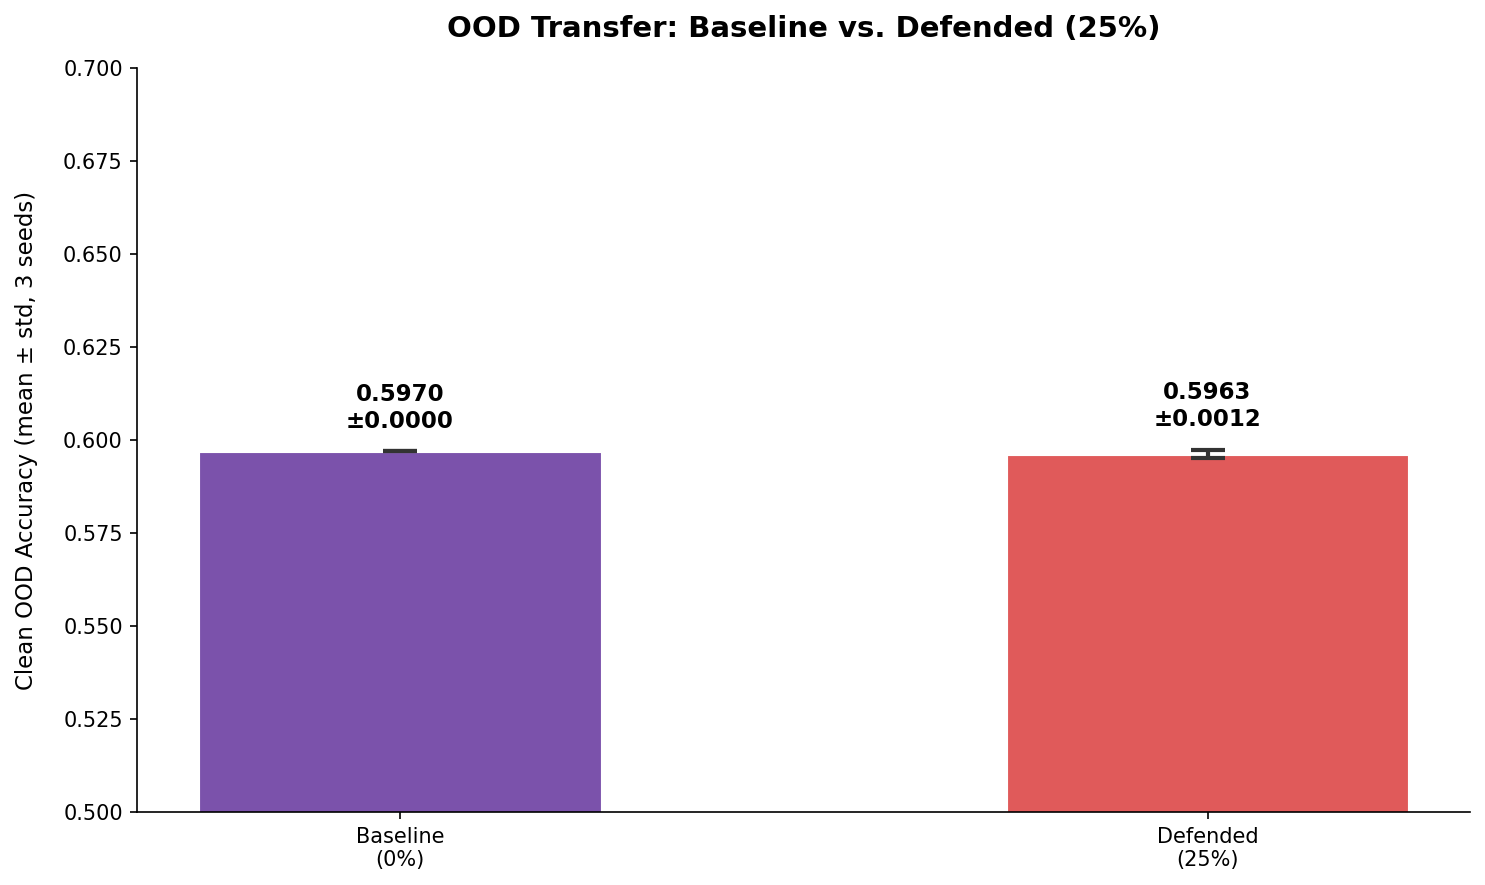

Figure 4 (with error bars) saved to ../results/13(3)_figure_4_ood_with_errorbars.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

models    = ['Baseline\n(0%)', 'Defended\n(25%)']
acc_means = [base_acc_mean, def_acc_mean]
acc_stds  = [base_acc_std,  def_acc_std]
colors    = [COLOR_PURPLE, COLOR_CORAL]

bars = ax.bar(models, acc_means, yerr=acc_stds, capsize=8,
              color=colors, edgecolor='white', linewidth=1.5,
              error_kw=dict(elinewidth=2, ecolor='#333333', capthick=2),
              width=0.5)

for bar, mean, std in zip(bars, acc_means, acc_stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.005,
            f'{mean:.4f}\n\u00b1{std:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='semibold')

ax.set_ylabel('Clean OOD Accuracy (mean \u00b1 std, 3 seeds)', labelpad=12)
ax.set_title('OOD Transfer: Baseline vs. Defended (25%)', fontsize=14, fontweight=600, pad=15)
ax.set_ylim(0.5, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out_path = '../results/13(3)_figure_4_ood_with_errorbars.png'
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Figure 4 (with error bars) saved to {out_path}')


## 6. Final Summary

In [7]:
acc_delta  = def_acc_mean  - base_acc_mean
drop_delta = def_drop_mean - base_drop_mean

print('='*60)
print('FINAL MULTI-SEED SUMMARY (3 seeds each)')
print('='*60)
print(f'Baseline   Clean OOD Acc : {base_acc_mean:.4f} ± {base_acc_std:.4f}')
print(f'Defended   Clean OOD Acc : {def_acc_mean:.4f}  ± {def_acc_std:.4f}')
print(f'Accuracy Delta           : {acc_delta:+.4f}')
print()
print(f'Baseline   Reward Drop   : {base_drop_mean:.4f} ± {base_drop_std:.4f}')
print(f'Defended   Reward Drop   : {def_drop_mean:.4f}  ± {def_drop_std:.4f}')
print(f'Robustness Delta         : {drop_delta:+.4f}')
print('='*60)
print('Files saved:')
print('  results/multi_seed_results.json')
print('  results/13(1)_table_1_multiseed_results.csv')
print('  results/13(2)_figure_3_ablation_with_errorbars.png')
print('  results/13(3)_figure_4_ood_with_errorbars.png')

FINAL MULTI-SEED SUMMARY (3 seeds each)
Baseline   Clean OOD Acc : 0.5970 ± 0.0000
Defended   Clean OOD Acc : 0.5963  ± 0.0012
Accuracy Delta           : -0.0007

Baseline   Reward Drop   : 1.4920 ± 0.0059
Defended   Reward Drop   : 1.4907  ± 0.0133
Robustness Delta         : -0.0013
Files saved:
  results/multi_seed_results.json
  results/13(1)_table_1_multiseed_results.csv
  results/13(2)_figure_3_ablation_with_errorbars.png
  results/13(3)_figure_4_ood_with_errorbars.png
